# Stacking of a simulated CMB temperature map

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

from cmbstack.main import StackingPipeline
from cmbstack import maps, stacking

In [2]:
fname = 'base_plikHM_TTTEEE_lowl_lowE_lensing.minimum.theory_cl'

## Run Peak Stacking Pipeline

The first step is to create a ``StackingPipeline`` object. This tutorial shows the stacking procedure for a simulated CMB temperature map from a theoretical power sepctrum using ``StackingPipeline.from_cl``. We can use `from_fits` or `from_map` when working with a real or pre-simulated map.  

In [3]:
pipeline = StackingPipeline.from_cl(fname, nside=1024, seed=42)

The stacked peak can then be obtained using the ``run`` method:

In [4]:
stacked_result = pipeline.run()

`stacked_result` stores every intermediate product as an attribute:

| Attribute | Content |
|---|---|
| `pipeline.map` | Raw simulated map |
| `pipeline.normalized` | Normalised map (units of $\sigma$) |
| `pipeline.positions` | Peak positions $(θ, φ)$ in radians |
| `pipeline.patches` | List of 2D gnomonic patches |
| `pipeline.stacked` | Mean stacked 2D image |
| `pipeline.radius` | Radial bin centres (arcmin) |
| `pipeline.profile` | Mean temperature per radial bin |

Below we describe how every intermediate product is obtained by running manually the functions that ``pipeline.run()``calls internally.

### 1. Load theoretical spectrum — `maps.load_cl`

The input file contains the power spectrum as $D_\ell^{TT}$:

$$D_\ell \equiv \frac{\ell(\ell+1)}{2\pi} C_\ell$$

`load_cl` reads columns $(\ell, D_\ell)$ and converts to $C_\ell$:

$$C_\ell = \frac{2\pi}{\ell(\ell+1)} D_\ell, \qquad C_0 = C_1 = 0$$

In [5]:
cl = maps.load_cl(fname)
type(cl)

numpy.ndarray

### 2. Simulate a Sky Map — `maps.simulate_map`

A Gaussian random realization is drawn by sampling spherical harmonic coefficients $a_{\ell m}$ with variance $C_\ell$:

$$T(\hat{n}) = \sum_{\ell,m} a_{\ell m} \, Y_{\ell m}(\hat{n}), \qquad \langle |a_{\ell m}|^2 \rangle = C_\ell$$

This calls `healpy.synfast` internally. An optional `seed` makes runs reproducible.

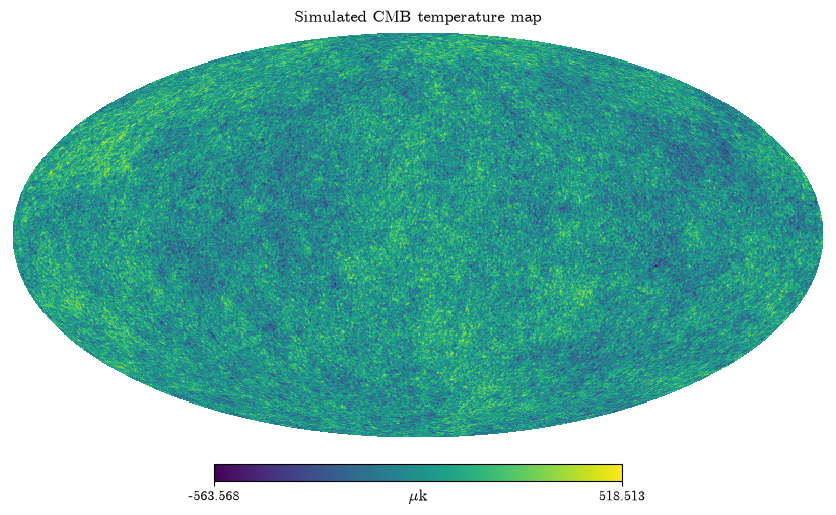

In [6]:
sim_map = maps.simulate_map(cl,nside=1024,seed=42)
hp.mollview(sim_map,title='Simulated CMB temperature map',unit=r'$\mu$k')

In [7]:
print("mean:", np.nanmean(sim_map))      
print("std: ", np.nanstd(sim_map))       # expect ~100 (μK)
print("min/max:", np.nanmin(sim_map), np.nanmax(sim_map))

mean: -1.0000346790661752e-06
std:  112.69465336088571
min/max: -587.8310256096638 535.185661970055


### 3. Normalise the Map — `maps.normalize_map`

Before peak detection, the map is standardised so that thresholds have a clear statistical meaning:

$$T_{\text{norm}}(\hat{n}) = \frac{T(\hat{n}) - \langle T \rangle}{\sigma}$$

After this step the map has mean $\approx 0$ and standard deviation $= 1$, so peaks are measured in units of $\sigma$.

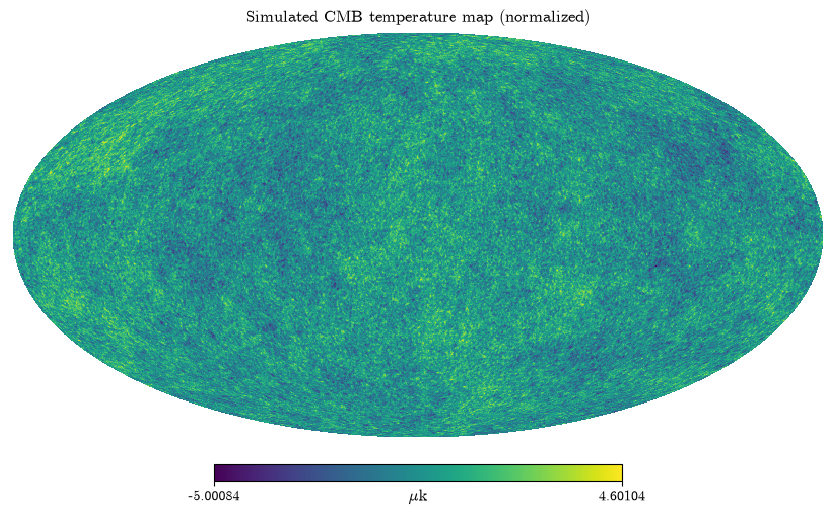

In [8]:
map_norm = maps.normalize_map(sim_map)
hp.mollview(map_norm,title='Simulated CMB temperature map (normalized)',unit=r'$\mu$k')

In [9]:
print("mean:", np.nanmean(map_norm))      # expect ~0 (monopole removed)
print("std: ", np.nanstd(map_norm))       # expect ~1 
print("min/max:", np.nanmin(map_norm), np.nanmax(map_norm)) # sigma units

mean: -3.700743415417188e-17
std:  0.9999999999999999
min/max: -5.216139427016107 4.748988944987899


### 4. Detect Peaks — `stacking.find_peaks`

Local maxima are identified with `healpy.hotspots`: a pixel is a maximum if its value exceeds every immediate HEALPix neighbour. Peaks are filtered by a significance threshold $\nu$ (default $\nu = 3\sigma$) and optionally capped at the $N$ highest:

$$\text{Peaks} = \{\hat{n}_p \in \text{Maxima} \mid T_{\text{norm}}(\hat{n}_p) > \nu\}$$

Returns sky positions as $(θ, φ)$ pairs in radians.

In [10]:
peak_positions = stacking.find_peaks(map_norm,1024,threshold=3,n_peaks=None)

### 5. Extract Patches — `stacking.extract_patches`

For each peak a square patch is cut using a gnomonic (tangent-plane) projection centred on $\hat{n}_p$. Every patch shares the same fixed pixel grid (side length `size_deg`, pixel scale `reso_arcmin`), so the centre pixel always corresponds to the peak itself and patches can be co-added directly.

In [11]:
patches = stacking.extract_patches(map_norm,peak_positions,size_deg=10,reso_arcmin=3)

### 6. Stack — `stacking.stack_patches`

Patches are averaged pixel-by-pixel:

$$S = \frac{1}{N} \sum_{i=1}^{N} P_i$$

Incoherent noise averages towards zero; the coherent central profile survives.

In [12]:
stacked = stacking.stack_patches(patches)

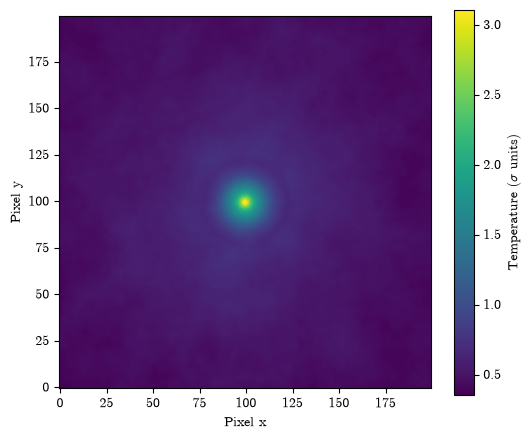

In [13]:
plt.figure(figsize=(6, 5))
plt.imshow(stacked,origin='lower')
plt.xlabel('Pixel x')
plt.ylabel('Pixel y')
plt.colorbar(label=r'Temperature ($\sigma$ units)')
plt.show()

### 7. Radial Profile — `stacking.radial_profile`

The 2D stacked image is collapsed to a 1D profile by azimuthal averaging in concentric annuli about the centre. Returns bin-centre radii in arcminutes and the mean temperature in each annulus.


In [14]:
radius, profile = stacking.radial_profile(stacked,reso_arcmin=3)

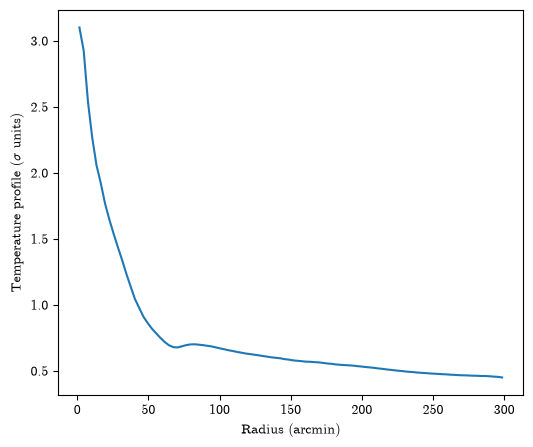

In [15]:
plt.figure(figsize=(6,5))
plt.plot(radius,profile)
plt.xlabel('Radius (arcmin)')
plt.ylabel(r'Temperature profile ($\sigma$ units)')
plt.show()

### Saving/loading the map – `maps.save_map`/`maps.load_map`

These functions wrap the healpy FITS readers for convenient saving/loading of the simulated maps.

In [16]:
maps.save_map("map_norm.fits", map_norm,overwrite=True) 

setting the output map dtype to [dtype('float64')]


In [17]:
m = maps.load_map("map_norm.fits", field=0)